# **Notebook 2 - Customer Segmentation** 

Afonso Fernandes 20241710, Lourenço Lima 20241711, Lucas Casimiro 20241796

## Imports

In [109]:
import os
import sys
import warnings
from pathlib import Path

def _find_project_root(start, marker="requirements.txt"):
    path = Path(start).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / marker).exists():
            return str(candidate)
    raise RuntimeError(f"Could not find project root (marker={marker!r}, searched from {start})")

PROJECT_ROOT = _find_project_root(os.path.abspath("."))
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [110]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
from pylab import rcParams
rcParams['figure.figsize'] = 30, 15
import umap

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
from functions.preprocessing import scale_features, FEATURE_COLS
from functions.clustering import *

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Scaling**

Before proceeding, we will save 3 scaled datasets using 3 different scalers, to see which one gives the better results.

In [111]:
clean_data = pd.read_csv('data/ci_clustering.csv')
clean_data

,customer_id,customer_name,customer_gender,kids_home,teens_home,number_complaints,distinct_stores_visited,typical_hour,lifetime_total_distinct_products,percentage_of_products_bought_promotion,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,3,Bsc. Crystal Kitchens,female,1.0,1.0,1.0,3.0,12.0,189.0,0.631599,...,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
1,4,Bsc. Glenda Bauman,female,1.0,0.0,0.0,2.0,12.0,130.0,0.149890,...,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
2,5,Msc. Antonio Campbell,male,0.0,0.0,0.0,2.0,11.0,81.0,0.069126,...,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
3,7,John Kelling,male,0.0,0.0,2.0,1.0,18.0,92.0,0.253609,...,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
4,8,Arthur Dematteo,male,0.0,0.0,3.0,1.0,17.0,6.0,0.186569,...,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31936,39996,Joshua Howard,male,0.0,0.0,2.0,1.0,12.0,162.0,0.261352,...,0.023845,0.677108,0.009538,0.028765,0.049900,0.051205,0.057932,0.003112,0.080221,0.018373
31937,39997,Anthony Hines,male,1.0,0.0,1.0,1.0,21.0,97.0,0.143479,...,0.285569,0.488076,0.009858,0.016836,0.048001,0.044817,0.020393,0.007453,0.071308,0.007690
31938,39998,Edna Hasselman,female,1.0,1.0,0.0,4.0,14.0,206.0,0.181917,...,0.569715,0.105017,0.113532,0.035053,0.008302,0.021784,0.000000,0.121975,0.006315,0.018307
31939,39999,George Kramer,male,1.0,1.0,1.0,6.0,11.0,385.0,0.807259,...,0.606702,0.225881,0.043232,0.021979,0.047947,0.000000,0.008197,0.029740,0.000000,0.016321


In [112]:
# Standard Scaler
clean_std = scale_features(clean_data.copy(), StandardScaler)

# Robust Scaler
clean_rb = scale_features(clean_data.copy(), RobustScaler)

# MinMax Scaler
clean_minmax = scale_features(clean_data.copy(), MinMaxScaler)

## **Clustering**

The cluster analysis in the notebook is separated by scalers, and in each section 2 algorithms will be tested: `K-means` and `Hierarchical (Ward linkage)`. 

For each scaler section, 3 tasks are developed:
 - **Mathematical Comparison**: silhouette scores (a common analysis between both models) is used as a comparison between algorithms and plotted for each amount of clusters.
 - **Visual Inspection**: an elbow method is plotted to decide an amount for k in K-means, and a dendrogram is plotted to decide the amount of clusters created by Hierarchical Ward algorithm.
 - **Cluster Analysis**: collect insights based on the clusters created from both algorithms (profiling).
  
We specifically use the *Ward* linkage for our hierarchical model because it minimizes within-cluster variance (the exact same mathematical objective as K-Means). Below is proof of this linkage method superiority.

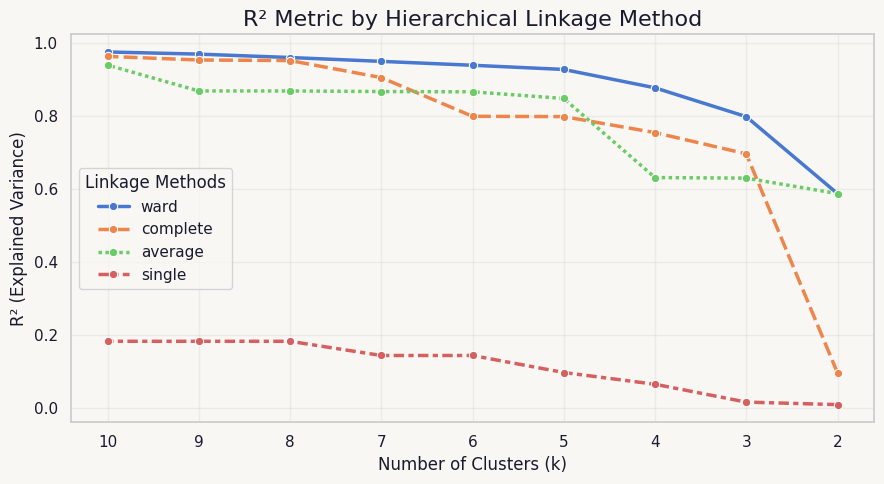

In [113]:
plot_r2_hc(clean_data, FEATURE_COLS)

## **Standard Scaler**

### Mathematical Comparison

In [114]:
results_std = compare_clustering_models(clean_std, FEATURE_COLS)
results_std

,model,k,silhouette
0,kmeans,3,0.141502
1,kmeans,6,0.128117
2,hierarchical_ward,3,0.126995
3,kmeans,7,0.122199
4,kmeans,5,0.118900
5,kmeans,10,0.111150
6,hierarchical_ward,9,0.108641
7,hierarchical_ward,6,0.107237
8,hierarchical_ward,8,0.103599
9,hierarchical_ward,4,0.103020


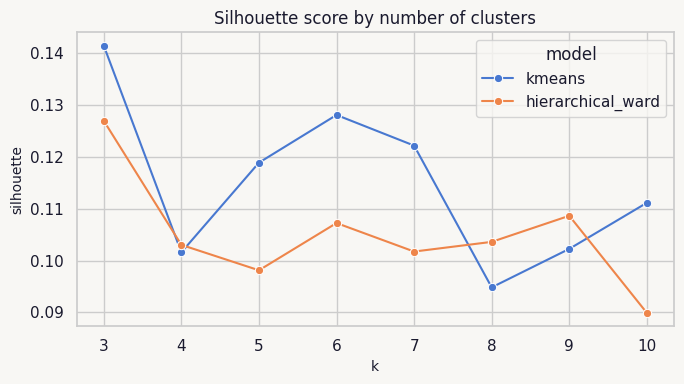

In [115]:
plot_metric_comparison(results_std)

### Visual Inspection

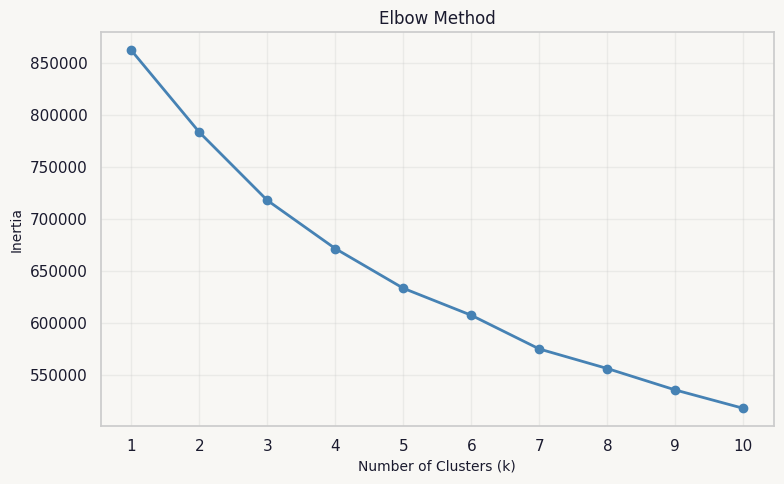

,k,inertia
0,1,862407.000000
1,2,783510.997242
2,3,717833.551258
3,4,671347.186374
4,5,633121.675174
5,6,607103.969192
6,7,574621.591434
7,8,555795.294825
8,9,535134.283536
9,10,517452.644186


In [116]:
compare_kmeans_inertia(clean_std, FEATURE_COLS)

From the elbow curve, k=5 could be a good result, as there's a bigger drop between 6 and 7 compared to 5 and 6, and its supported by the silhouette score as the best result for k-means (with this scaler). # without share_groceries

with share groceries, k=6

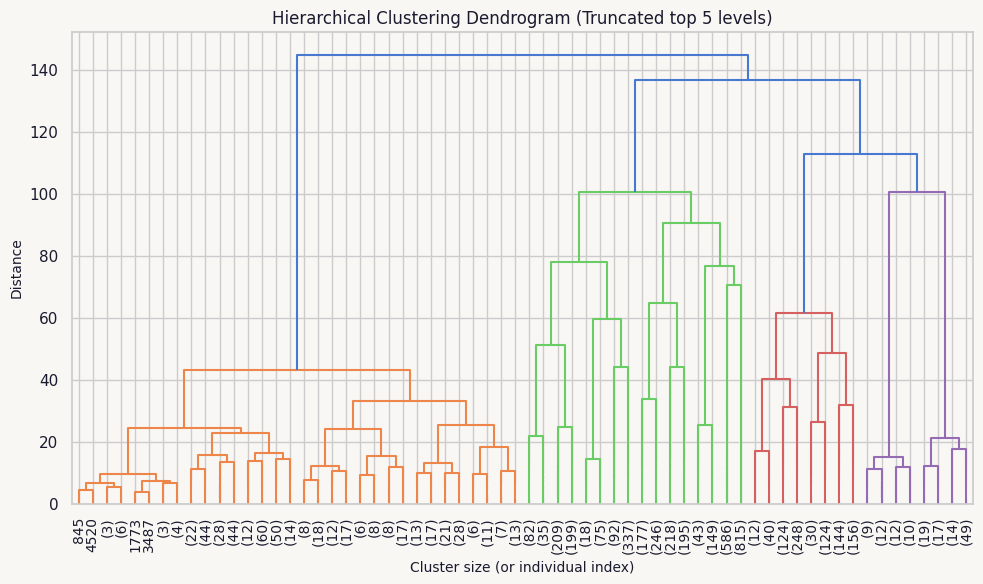

In [117]:
plot_dendrogram(clean_std, FEATURE_COLS)

The first small drop in distance comes at either 5 or 7 clusters (depending on what we consider small). Supported by the silhouette score analysis, we will proceed with 7 clusters for the hierarchical clustering.

# With share_groceries k=7

### Cluster Analysis

In [121]:
optimal_k_kmeans_std = 6
optimal_k_ward_std = 6

In [ ]:
kmeans_labels_std, kmeans_model_std = fit_final_kmeans(clean_std, FEATURE_COLS, n_clusters=optimal_k_kmeans_std)
final_std_k = add_clusters(clean_data, kmeans_labels_std, cluster_col='std_kmeans6')

calculate_group_means(final_std_k, cluster_col='std_kmeans6')

std_kmeans5,0,1,2,3,4,5
customer_id,21022.442224,19857.906634,19262.097746,19884.372146,19274.217911,20042.779746
kids_home,1.015871,1.016772,2.991040,1.025114,0.836491,0.261293
teens_home,0.580384,0.861908,2.436872,0.845890,0.812582,0.312666
number_complaints,1.183375,0.642564,0.932935,0.702055,0.760815,1.038382
distinct_stores_visited,3.258278,3.418189,3.346457,3.414384,3.352447,1.530853
typical_hour,12.689884,12.286247,10.426283,12.309361,11.933036,17.382344
lifetime_total_distinct_products,86.983444,105.060007,304.295411,103.291096,187.946409,107.951875
percentage_of_products_bought_promotion,0.535216,0.136296,0.226216,0.162964,0.306694,0.264651
year_first_transaction,2017.006623,2015.724376,2012.846592,2015.681507,2013.573701,2017.255683
latitude,38.747091,38.755726,38.748402,38.754294,38.749233,38.747988


 - Cluster 0: Highest complaints average, with the biggest percentage of products bought in promotion. Youngest and smaller spend
 - Cluster 1: 
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:

In [ ]:
ward_labels_std, ward_model_std = fit_final_hierarchical(clean_std, FEATURE_COLS, n_clusters=optimal_k_ward_std)
final_std_ward = add_clusters(clean_data, ward_labels_std, cluster_col='std_ward6')

calculate_group_means(final_std_ward, cluster_col='std_ward6')

std_ward7,0,1,2,3,4,5
customer_id,20457.633649,18871.921333,19786.487267,19767.076588,19724.335103,20085.257840
kids_home,0.971306,2.031500,1.028862,0.299681,1.026550,1.017422
teens_home,0.740655,1.653500,0.847199,0.330142,0.871989,0.843206
number_complaints,0.963597,0.947167,0.719864,1.028431,0.625261,0.665505
distinct_stores_visited,3.202019,3.659667,3.434635,1.585147,3.360705,3.372822
typical_hour,11.983909,11.966333,12.505942,17.035683,12.466148,11.905923
lifetime_total_distinct_products,130.086143,273.412167,99.684211,105.826516,101.575953,110.693380
percentage_of_products_bought_promotion,0.404766,0.319275,0.169521,0.274495,0.132362,0.149508
year_first_transaction,2015.748730,2012.656667,2015.711375,2017.176385,2015.267590,2015.620209
latitude,38.748466,38.748082,38.752666,38.748556,38.755033,38.757635


 - Cluster 0: 
 - Cluster 1: 
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:
 - Cluster 6:

## **Robust Scaler**

### Mathematical Comparison

In [124]:
results_rb = compare_clustering_models(clean_rb, FEATURE_COLS)
results_rb

,model,k,silhouette
0,hierarchical_ward,3,0.275580
1,kmeans,3,0.236978
2,kmeans,4,0.192817
3,hierarchical_ward,4,0.167252
4,kmeans,5,0.145517
5,kmeans,6,0.137810
6,kmeans,8,0.135506
7,kmeans,7,0.131794
8,hierarchical_ward,5,0.130481
9,hierarchical_ward,9,0.127245


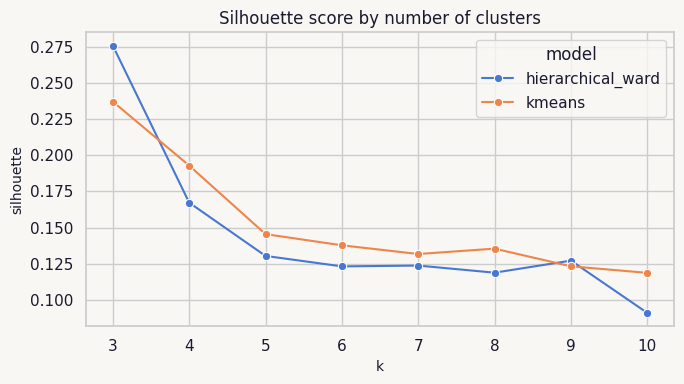

In [125]:
plot_metric_comparison(results_rb)

From the silhouette score comparison, both start at their highest value, at k=3. However, 3 clusters are too broad to be useful. We can see both models hit a plateau at k=5.

### Visual Inspection

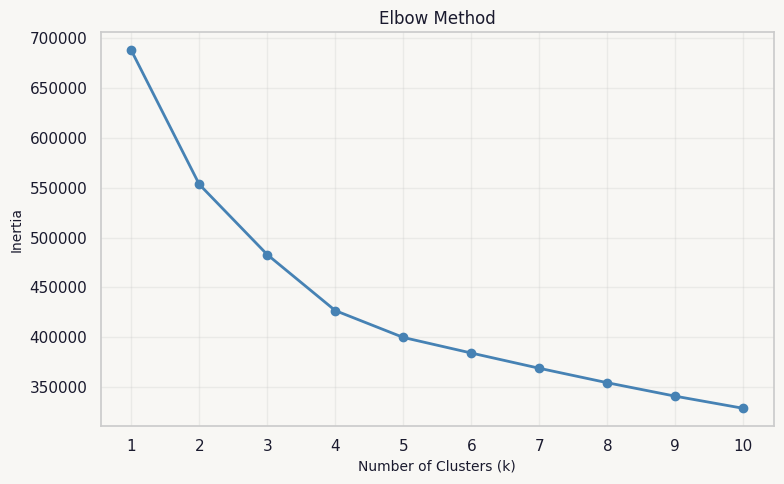

,k,inertia
0,1,688122.817366
1,2,553399.115374
2,3,482816.818638
3,4,426592.664862
4,5,399611.837386
5,6,383953.463865
6,7,368636.721768
7,8,354113.460252
8,9,340589.793625
9,10,328393.492164


In [126]:
compare_kmeans_inertia(clean_rb, FEATURE_COLS)

From the elbow method, we can see a bend at k=4 and k=5, before the line flattens out. To provide a more precise analysis, we will proceed with k=5 for k-means.

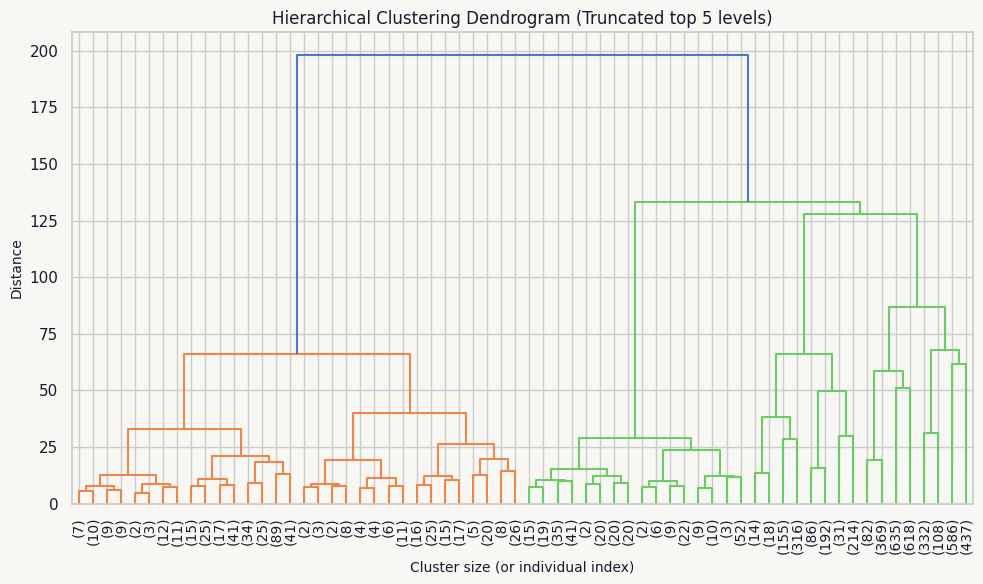

In [127]:
plot_dendrogram(clean_rb, FEATURE_COLS)

From the dendrogram, if we go based on the colors (Scipy indicator), then 3 clusters is suggested. However, considering our business needs, 3 clusters is too few, and 5 clusters sits at the beginning of the plateau on the silhouette scores mapping, indicating stability. So, we have decide to continue with 5 clusters.

### Cluster Analysis

In [132]:
optimal_k_kmeans_rb = 4
optimal_k_ward_rb = 4

In [133]:
kmeans_labels_rb, kmeans_model_rb = fit_final_kmeans(clean_rb, FEATURE_COLS, n_clusters=optimal_k_kmeans_rb)
final_rb_kmeans = add_clusters(clean_data, kmeans_labels_rb, cluster_col='rb_kmeans')

calculate_group_means(final_rb_kmeans, cluster_col='rb_kmeans')

rb_kmeans,0,1,2,3
customer_id,20043.504789,19653.412298,19776.926056,19983.825492
kids_home,0.917543,3.517473,1.000800,0.302823
teens_home,0.704060,2.835013,0.858515,0.335900
number_complaints,0.952473,0.961022,0.646927,1.052466
distinct_stores_visited,3.311140,3.215390,3.437580,1.658683
typical_hour,12.317283,10.292675,12.219270,16.915312
lifetime_total_distinct_products,146.537428,291.243280,112.424616,106.488452
percentage_of_products_bought_promotion,0.398187,0.218681,0.168186,0.275915
year_first_transaction,2015.118532,2013.225806,2015.539533,2017.087254
latitude,38.748410,38.748128,38.754758,38.748614


 - Cluster 0: 50% of products bought in promotions, highest average for number of complaints and lowest for total spend. Also the youngest cluster.
 - Cluster 1: Very high average of dependants, with long tenure and high total spend. Also has the most distinct products bought.
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:

In [134]:
ward_labels_rb, ward_model_rb = fit_final_hierarchical(clean_rb, FEATURE_COLS, n_clusters=optimal_k_ward_rb)
final_rb_ward = add_clusters(clean_data, ward_labels_rb, cluster_col='rb_ward')

calculate_group_means(final_rb_ward, cluster_col='rb_ward')

rb_ward,0,1,2,3
customer_id,20069.146950,19768.898167,19634.203130,19952.279233
kids_home,0.905719,1.029579,3.211397,0.329463
teens_home,0.686111,0.879988,2.617656,0.358898
number_complaints,0.975490,0.624095,0.914379,1.034837
distinct_stores_visited,3.325708,3.384378,3.300856,1.691331
typical_hour,12.286492,12.439686,10.310599,16.652984
lifetime_total_distinct_products,146.550272,101.359267,298.978152,107.043748
percentage_of_products_bought_promotion,0.421021,0.131467,0.212613,0.274109
year_first_transaction,2015.151307,2015.571869,2013.115737,2017.046989
latitude,38.748308,38.754706,38.748277,38.748676


 - Cluster 0: 
 - Cluster 1: 
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:

## **MinMax Scaler**

In [135]:
results_minmax = compare_clustering_models(clean_minmax, FEATURE_COLS)
results_minmax

,model,k,silhouette
0,kmeans,4,0.227605
1,hierarchical_ward,5,0.212828
2,kmeans,3,0.201824
3,hierarchical_ward,4,0.201375
4,kmeans,5,0.197034
5,hierarchical_ward,3,0.185375
6,kmeans,6,0.185122
7,hierarchical_ward,6,0.177710
8,hierarchical_ward,9,0.175236
9,hierarchical_ward,8,0.169558


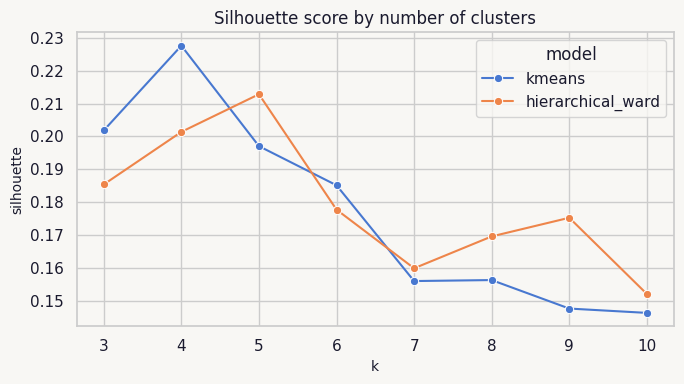

In [136]:
plot_metric_comparison(results_minmax)

### Visual Inspection

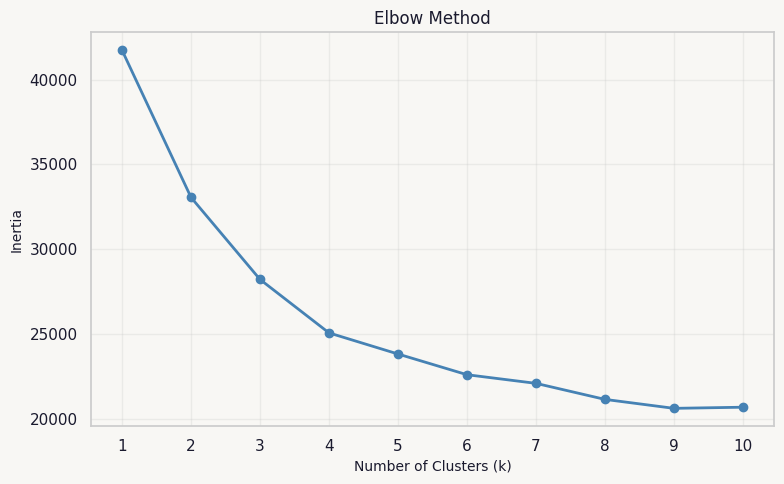

,k,inertia
0,1,41734.004936
1,2,33057.334571
2,3,28220.929560
3,4,25069.837682
4,5,23825.426463
5,6,22605.052341
6,7,22095.457614
7,8,21149.667446
8,9,20622.309878
9,10,20689.083457


In [137]:
compare_kmeans_inertia(clean_minmax, FEATURE_COLS)

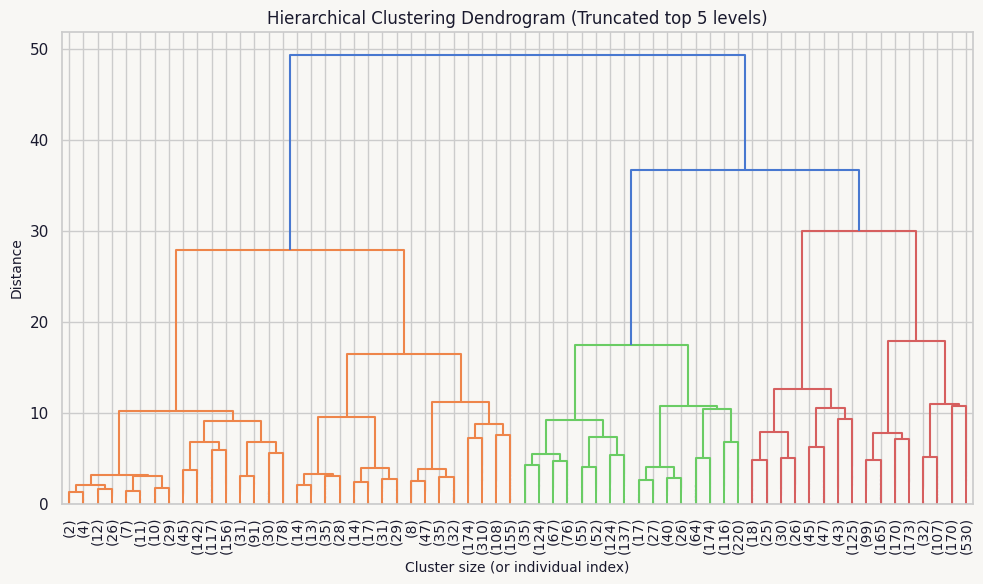

In [138]:
plot_dendrogram(clean_minmax, FEATURE_COLS)

### Cluster Analysis

In [142]:
optimal_k_kmeans_minmax = 5
optimal_k_ward_minmax = 5

In [143]:
kmeans_labels_minmax, kmeans_model_minmax = fit_final_kmeans(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_kmeans_minmax)
final_minmax_kmeans = add_clusters(clean_data, kmeans_labels_minmax, cluster_col='minmax_kmeans')

calculate_group_means(final_minmax_kmeans, cluster_col='minmax_kmeans')

minmax_kmeans,0,1,2,3,4
customer_id,29583.287902,10639.879832,13623.083264,16224.934017,29544.496293
kids_home,1.077524,1.193060,1.132645,1.018453,1.122502
teens_home,0.793060,1.045878,0.961570,0.828518,0.835912
number_complaints,0.961707,0.758966,0.882025,0.956384,0.936331
distinct_stores_visited,3.116912,3.292035,3.185537,3.046971,3.096389
typical_hour,13.026415,11.798090,12.352066,12.870829,12.941651
lifetime_total_distinct_products,142.933573,166.118072,155.075310,137.390867,143.710026
percentage_of_products_bought_promotion,0.314226,0.277448,0.330595,0.373049,0.308686
year_first_transaction,2015.992810,2014.503260,2014.729132,2014.931034,2016.041425
latitude,38.749534,38.750447,38.749782,38.749024,38.749541


 - Cluster 0: 
 - Cluster 1: 
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:

In [144]:
ward_labels_minmax, ward_model_minmax = fit_final_hierarchical(clean_minmax, FEATURE_COLS, n_clusters=optimal_k_ward_minmax)
final_minmax_ward = add_clusters(clean_data, ward_labels_minmax, cluster_col='minmax_ward')

calculate_group_means(final_minmax_ward, cluster_col='minmax_ward')

minmax_ward,0,1,2,3,4
customer_id,13827.159382,27501.140990,13985.480521,29511.260464,19739.237993
kids_home,1.096541,1.035325,1.209987,1.080156,1.068182
teens_home,0.930486,0.781357,1.017248,0.799187,0.843482
number_complaints,0.877433,0.954871,0.880835,0.972378,0.782161
distinct_stores_visited,3.147370,2.909275,3.320227,3.103711,3.274014
typical_hour,12.401513,13.448491,11.939091,13.055245,12.421098
lifetime_total_distinct_products,151.662996,141.068005,161.099264,144.668022,127.848628
percentage_of_products_bought_promotion,0.334073,0.306809,0.342575,0.318799,0.266602
year_first_transaction,2014.713825,2016.161220,2014.498734,2015.984579,2015.490995
latitude,38.749536,38.749210,38.749784,38.749423,38.751371


 - Cluster 0: 
 - Cluster 1:
 - Cluster 2:
 - Cluster 3:
 - Cluster 4:
 - Cluster 5:

## **Final Clustering Solution**